Cross-Validation Accuracy: 86.89%
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.71      0.83        28
           1       0.84      1.00      0.91        43

    accuracy                           0.89        71
   macro avg       0.92      0.86      0.87        71
weighted avg       0.90      0.89      0.88        71



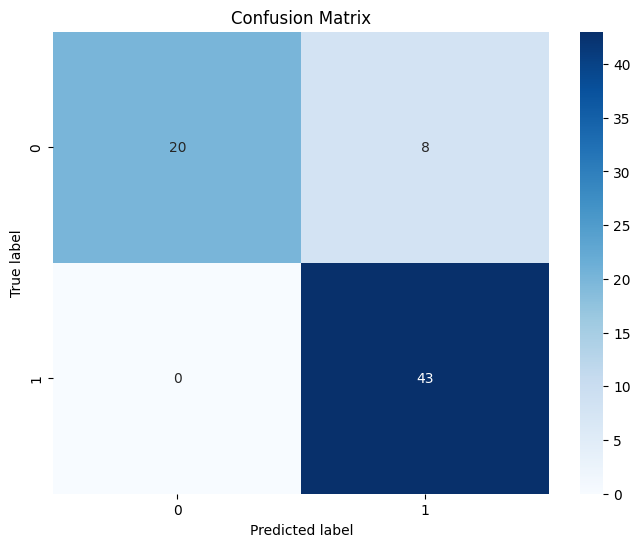

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix as sklearn_confusion_matrix,
)

data = pd.read_csv("./ion_binary_classification.csv")
data = data.drop(columns=["Unnamed: 0"])
data["Class"] = data["Class"].map({"good": 1, "bad": 0})
data.iloc[:, :-1] = data.iloc[:, :-1].apply(pd.to_numeric, errors="coerce")

X = data.drop(columns=["Class"])
Y = data["Class"]
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

pipeline = make_pipeline(StandardScaler(), GaussianNB())
pipeline.fit(X_train, Y_train)
y_pred_sklearn = pipeline.predict(X_test)

scores = cross_val_score(pipeline, X, Y, cv=5, scoring="accuracy")
print(f"Cross-Validation Accuracy: {np.mean(scores) * 100:.2f}%")

print("Classification Report:\n", classification_report(Y_test, y_pred_sklearn))

confusion_matrix_sklearn = sklearn_confusion_matrix(Y_test, y_pred_sklearn)

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_sklearn, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.show()